In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-bright')
plt.rcParams["font.family"] = "monospace"
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.bottom'] = True
from skimage import io

import import_helper
import_helper.add_functions()
import organoid_analysis.geometrical_organoid_analysis as geo
from scipy.interpolate import splprep

### Plot isolines that are the shortest distance to an edge for each point 

In [293]:
# rotation of image
folder_path = "../example_data/220526/square_800"
all_images = os.listdir(folder_path)
dataname = all_images[4]
print(dataname)
path = os.path.join(folder_path, dataname)
print(path)
img = io.imread(path)
# extract DAPI and TBXT channels
DAPI_channel, TBXT_channel = img[:,:,2], img[:,:,1]

# process to get less noisy binary image
DAPI_binary = geo.get_binary_image(DAPI_channel, 
                                   intensity_threshold=200, #200 #150, #200, #500, #150
                                   area_threshold=10**5,
                                   binary_dilation_iter=10,
                                   binary_closing_iter=50)
# obtain contour of organoid and the centre
contour, centre = geo.get_contour_and_centroid(DAPI_binary,
                                               area_threshold=10**5)
contour = geo.shrink_contour(contour, centre, 0.98)

max_dist, _ = geo.get_max_dist_min_dist(contour, centre)

Maxproj_20260521_J29_20X_square_48hr_800um_04.tif.tif
../example_data/220526/square_800/Maxproj_20260521_J29_20X_square_48hr_800um_04.tif.tif


In [294]:
# get function to fit the contour
contour_xy = [contour[:,0], contour[:,1]]
tck, u = splprep(contour_xy, s=10**4, per=True)

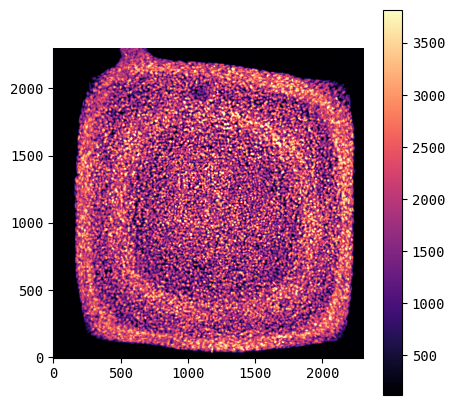

In [295]:
### plot to view if rotated results are correct
fig, ax = plt.subplots(figsize=(5,5))
im = ax.imshow(DAPI_channel, 
               origin="lower", 
               vmin=np.percentile(DAPI_channel, 1), 
               vmax=np.percentile(DAPI_channel, 99), 
               cmap="magma")
# ax.scatter(centre[1], centre[0], marker="x", color="cyan")
# ax.scatter(contour[:,1], contour[:,0], s=0.05, color="red")
fig.colorbar(im)
# ax.set_xlim(50, 1000)
# ax.set_ylim(0, 1000)
# ax.set_xticks([])
# ax.set_yticks([])
# fig.savefig("DAPI_triangle.png", transparent=True)

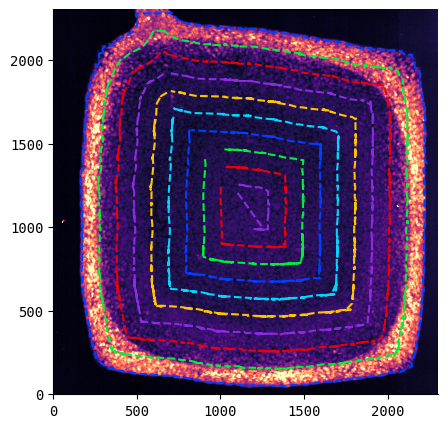

In [296]:
n = 14  # number of inner contours
distances = np.linspace(0, max_dist, n)
tol = 5

t = np.linspace(0, 1, 1000)

fig, ax = plt.subplots(figsize=(5, 5))

# ax[0].imshow(DAPI_channel, origin="lower", vmin=np.percentile(img, 1), vmax=np.percentile(img, 99), cmap="magma")
# geo.plot_contours(distances, tol, t, tck, ax[0])

ax.imshow(TBXT_channel, 
          origin="lower", 
          vmin=np.percentile(TBXT_channel, 1), 
          vmax=np.percentile(TBXT_channel, 99), 
          cmap="magma")
# ax.scatter(contour[:,1], contour[:,0], s=0.05, color="red")
geo.plot_contours(distances, tol, t, tck, ax)

In [297]:
n_output = 10
n = 100  # number of inner contours
distances = np.linspace(0, max_dist, n)
tol = 10

TBXT_contour_intensity = geo.intensity_from_contours(n_output, 
                                                     TBXT_channel, 
                                                     distances, 
                                                     tol, 
                                                     t, 
                                                     tck)
DAPI_contour_intensity = geo.intensity_from_contours(n_output, 
                                                     DAPI_channel, 
                                                     distances, 
                                                     tol, 
                                                     t, 
                                                     tck)
TBXT_DAPI = TBXT_contour_intensity/DAPI_contour_intensity
normalised_TBXT = (TBXT_DAPI - TBXT_DAPI.min()) / (TBXT_DAPI.max() - TBXT_DAPI.min())

(0.0, 1.0)

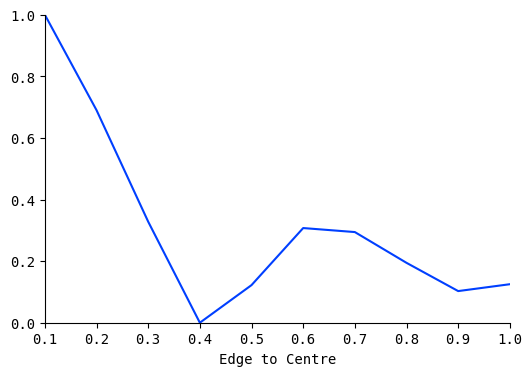

In [298]:
fig, ax = plt.subplots(figsize=(6, 4))
x = np.linspace(0, 1, n_output+1)[1:]
ax.plot(x, normalised_TBXT)
ax.set_xlabel("Edge to Centre")
ax.set_xlim(x[0], 1)
ax.set_ylim(0, 1)

In [284]:
# open the file, add new column and save
df = pd.read_csv("../contour_intensities/norm_tbxt_ctrl_square_48hr_800um.csv")
df[dataname] = normalised_TBXT
df.to_csv("../contour_intensities/norm_tbxt_ctrl_square_48hr_800um.csv", index=False)

#### Plot results of multiple images

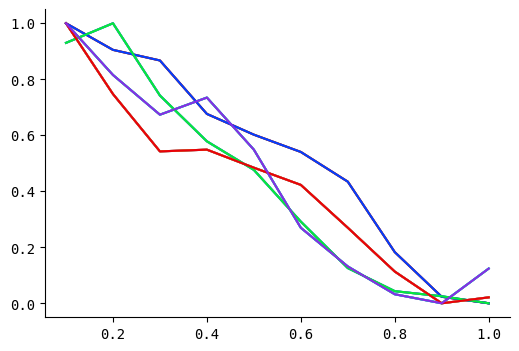

In [9]:
folder_name = "../contour_intensities"
file_name = "norm_tbxt_ctrl_triangle_48hr_350um.csv"
file_path = os.path.join(folder_name, file_name)
dataframe = pd.read_csv(file_path)

image_names = dataframe.columns.to_numpy()[2:]
distance = dataframe["distance"]

fig, ax = plt.subplots(figsize=(6, 4))
for i in range(len(image_names)):
    ax.plot(distance, dataframe[image_names].to_numpy())